# Teste de hipóteses



---



https://www.youtube.com/watch?v=0oc49DyA3hU "Hypothesis Testing and The Null Hypothesis" - StatQuest

O teste de hipóteses é uma ferramenta de inferência estatística que utiliza dados de uma amostra para decidir entre duas afirmações contraditórias sobre um parâmetro populacional.

#### *As Hipóteses:*

**Hipótese Nula (H₀):**  
É a afirmação assumida como verdadeira inicialmente (análoga à "inocência" em um tribunal).  
Geralmente representa o estado de igualdade ou ausência de efeito.  
- A pessoa é "inocente" até que se prove o contrário

Exemplo:  
H₀: θ = θ₀  


**Hipótese Alternativa (H₁ ou Hₐ):**  
É a afirmação que queremos provar, sendo contrária à H₀.
- Precisamos coletar provas (dados) para provar que a pessoa é "culpada"

Pode ser:

- **Unilateral:**  
  θ > θ₀ ou θ < θ₀  

- **Bilateral:**  
  θ ≠ θ₀  




#### *Erros de Decisão*

Ao realizar um teste, podemos cometer dois tipos de erros:

**Erro do Tipo I (α):**  
Rejeitar H₀ quando ela é verdadeira (falso positivo).  
A probabilidade α é chamada de **nível de significância**.



**Erro do Tipo II (β):**  
Não rejeitar H₀ quando ela é falsa (falso negativo).




#### *Valor-p (p-value)*

É o menor nível de significância (α) para o qual podemos rejeitar H₀.

**Interpretação:**  
Probabilidade de observar os dados atuais (ou algo mais extremo), assumindo que H₀ é verdadeira.

**Regra de decisão:**

- Se p-value ≤ α → **Rejeitar H₀**
- Se p-value > α → **Não rejeitar H₀**

Quanto menor o p-value, maior a evidência contra H₀.

---

Relevância para Data Science

**A/B Testing:**  
Fundamental para decidir se uma mudança (em site, algoritmo ou produto) gerou impacto real ou foi apenas aleatória.


**Seleção de Atributos:**  
Ajuda a verificar se variáveis têm relação estatisticamente significativa com o alvo.


**Validação de Modelos:**  
Permite testar se melhorias de performance são reais ou apenas resultado da amostra.


**Tomada de Decisão Baseada em Dados:**  
Fornece um critério rigoroso para evitar decisões baseadas apenas em intuição.

---

Em inferência estatística, uma hipótese é feita com relação a um parâmetro da população.  Para testar uma hipótese, extraímos amostras independentes e identicamente distribuídas. Analisando essa amostra, podendo chegar a duas possíveis decisões:
* Falhar na rejeição da hipótese nula (aceitar $H_0$).
* Rejeitar a hipótese nula.

**Exemplo:** Em uma fábrica, engenheiros verificaram que o tempo de funcionamento de uma máquina até que ocorra uma falha, é normalmente distribuído com média igual a 206 dias, com desvio padrão igual a 12 dias.  Uma atualização de componentes foi feita em 30 máquinas, de modo a deixá-las mais robustas e aumentar esse tempo de funcionamento.  Nessa amostra,  verificou-se que o tempo médio até falhar foi de 210 dias.  Ao nível 10\%, podemos acreditar que a atualização deixou as máquinas mais robustas?

Como hipótese nula, vamos assumir que a atualização não aumentou o tempo de funcionamento. Assim, temos as hipóteses:
* $H_0: \mu = 206$ dias
* $H_1: \mu > 206$ dias

In [ ]:
import scipy.stats as st

# Dados do problema
mu = 206
sigma = 12
n = 30
media_amostral = 210
nivel_significancia = 0.10

# Hipóteses
# H0: mu = 206 (a atualização não afetou o tempo de funcionamento)
# H1: mu > 206 (a atualização aumentou o tempo de funcionamento)

# Cálculo do valor crítico (z_critico) para um teste unilateral à direita (>)
z = st.norm.ppf(1 - nivel_significancia)
x_critico = mu + z*sigma/np.sqrt(n)
print(f"Região crítica: > {x_critico}")
print(f"Média amostral observada: {media_amostral}")

if media_amostral > x_critico:
    print("Rejeita-se H0. A atualização aumentou o tempo de funcionamento das máquinas.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que a atualização aumentou o tempo de funcionamento das máquinas.")

Região crítica: > 208.80773880421935
Média amostral observada: 210
Rejeita-se H0. A atualização aumentou o tempo de funcionamento das máquinas.




---



**Exemplo:** Uma empresa acredita que o seu novo vídeo com propaganda de produtos em promoção  aumenta o interesse de usuários.  O vídeo anterior era visualizado, em média, por 12 segundos.  Uma amostra de 5 visualizações do novo vídeo ofereceu o seguintes valores (em segundos): 14,4; 12,9; 15; 13,7; 13,5.  Qual conclusão a empresa pode chegar ao nível de 1\% de significância?

Como a empresa está interessada em verificar se o novo vídeo é mais interessante para o usuário do que o vídeo anterior, estabelecemos a seguintes hipóteses:
* $H_0: \mu = 12s$
* $H_1: \mu > 12s$

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
mu = 12
amostra = np.array([14.4, 12.9, 15, 13.7, 13.5])
n = len(amostra)
nivel_significancia = 0.01

# Hipóteses
# H0: mu = 12 (o novo vídeo não aumenta o interesse dos usuários)
# H1: mu > 12 (o novo vídeo aumenta o interesse dos usuários)

# Cálculo da média amostral e do desvio padrão amostral
media_amostral = np.mean(amostra)
desvio_padrao_amostral = np.std(amostra, ddof=1)  # ddof=1 para desvio padrão amostral

# Cálculo do valor crítico (t_critico) para um teste unilateral à direita (>) com n-1 graus de liberdade
t = st.t.ppf(1 - nivel_significancia, n - 1)
print('t crítico:',t)
x_critico = mu + t*desvio_padrao_amostral/np.sqrt(n)
print(f"Região crítica: > {x_critico}")
print(f"Média amostral observada: {media_amostral}")

if media_amostral > x_critico:
    print("Rejeita-se H0. O novo vídeo aumenta o interesse dos usuários.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que o novo vídeo aumenta o interesse dos usuários.")

t crítico: 3.7469473879811366
Região crítica: > 13.366480427545056
Média amostral observada: 13.9
Rejeita-se H0. O novo vídeo aumenta o interesse dos usuários.




---



**Exemplo:** Em uma cidade,  acredita-se que 60\% das pessoas aprovam o atual prefeito.  Uma pesquisa foi realizada com 200 indivíduos, onde verificou-se que 104 disseram que aprovam o atual governo.  Faça um teste ao nível 5\% para determinar se a aprovação do prefeito é realmente igual a 60\%.

$$
\begin{aligned}
&H_0: p = 0,6\\
&H_1: p < 0,6.
\end{aligned}
$$

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
p = 0.6
n = 200
x = 104
nivel_significancia = 0.05

# Hipóteses
# H0: p = 0.6 (a aprovação do prefeito é igual a 60%)
# H1: p < 0.6 (a aprovação do prefeito é menor que 60%)

# Proporção amostral
p_chapeu = x / n

# Cálculo do valor crítico (z_critico) para um teste unilateral à esquerda (<)
z = st.norm.ppf(nivel_significancia)

# Cálculo da proporção crítica
p_critico = p + z * np.sqrt(p * (1 - p) / n)
print(f"Região crítica: < {p_critico}")
print(f"Proporção amostral observada: {p_chapeu}")

if p_chapeu < p_critico:
    print("Rejeita-se H0. A aprovação do prefeito é menor que 60%.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que a aprovação do prefeito é menor que 60%.")

Região crítica: < 0.5430205989421221
Proporção amostral observada: 0.52
Rejeita-se H0. A aprovação do prefeito é menor que 60%.


Como $\hat{p}_{\mathrm{obs}} < \hat{p}_c $, rejeitamos $H_0$ ao nível de 5\%. Ou seja,  a fração de pessoas que aprovam o atual prefeito é menor do que 60\%.



---



**Exemplo**: Uma fábrica anuncia que o índice de nicotina dos cigarros de uma dada marca é igual a 20 mg por cigarro. Um laboratório realiza 20 análises do índice obtendo: 22, 19, 21, 22, 20, 18, 27, 20, 21, 19, 20, 22, 17, 20, 21,18, 25, 16, 20, 21. Sabe-se que o índice de nicotina dos cigarros dessa marca se distribui normalmente com variância 4 mg$^2$. Pode-se aceitar a afirmação do fabricante, ao nível de 5%?

$H_0: \mu = 20$<br>
$H_1: \mu > 20$

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
mu = 20
n = 20
amostra = np.array([22, 19, 21, 22, 20, 18, 27, 20, 21, 19, 20, 22, 17, 20, 21, 18, 25, 16, 20, 21])
variancia = 4
nivel_significancia = 0.05

# Hipóteses
# H0: mu = 20 (o índice de nicotina é igual a 20 mg)
# H1: mu > 20 (o índice de nicotina é maior que 20 mg)

# Cálculo da média amostral
media_amostral = np.mean(amostra)

# Cálculo do desvio padrão populacional
desvio_padrao = np.sqrt(variancia)

# Cálculo do valor crítico (z_critico) para um teste unilateral à direita (>)
z = st.norm.ppf(1 - nivel_significancia)
x_critico = mu + z * desvio_padrao / np.sqrt(n)
print(f"Região crítica: > {x_critico}")
print(f"Média amostral observada: {media_amostral}")

if media_amostral > x_critico:
    print("Rejeita-se H0. O índice de nicotina é maior que 20 mg.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que o índice de nicotina é maior que 20 mg.")

Região crítica: > 20.735600904580114
Média amostral observada: 20.45
Falha em rejeitar H0. Não há evidências suficientes para afirmar que o índice de nicotina é maior que 20 mg.




---



**Exemplo**: Um pesquisador deseja estudar o efeito de certa substância no tempo de reação de seres vivos a um certo tipo de estímulo. Um experimento é desenvolvido com cobaias, que são inoculadas com a substância e submetidas a um estímulo elétrico, com seus tempos de reação (em segundos) anotados. Os seguintes valores foram obtidos:
T = [9,1;9,3;7,2;13,3;10,9;7,2;9,9;8,0;8,6;7,5]<br>
Admite-se que, em geral,  o tempo de reação tem distribuição Normal com média 8 segundos e desvio padrão 2 segundos. Entretanto, o pesquisador desconfia que o tempo médio sofre alteração por influência da substância. Verifique a nível 6% se o tempo de reação das cobaias submetidas à substância foi alterado.

$H_0: \mu = 8$<br>
$H_1: \mu \neq 8$

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
mu = 8
sigma = 2
n = 10
amostra = np.array([9.1, 9.3, 7.2, 13.3, 10.9, 7.2, 9.9, 8.0, 8.6, 7.5])
nivel_significancia = 0.06

# Hipóteses
# H0: mu = 8 (o tempo de reação não foi alterado)
# H1: mu != 8 (o tempo de reação foi alterado)

# Cálculo da média amostral
media_amostral = np.mean(amostra)

# Cálculo dos valores críticos (z_critico) para um teste bilateral
z_critico_inferior = st.norm.ppf(nivel_significancia / 2)
z_critico_superior = st.norm.ppf(1 - nivel_significancia / 2)

x_critico_inferior = mu + z_critico_inferior * sigma / np.sqrt(n)
x_critico_superior = mu + z_critico_superior * sigma / np.sqrt(n)

print(f"Região crítica: < {x_critico_inferior} ou > {x_critico_superior}")
print(f"Média amostral observada: {media_amostral}")

if media_amostral < x_critico_inferior or media_amostral > x_critico_superior:
    print("Rejeita-se H0. O tempo de reação foi alterado.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que o tempo de reação foi alterado.")

Região crítica: < 6.810481677911164 ou > 9.189518322088837
Média amostral observada: 9.1
Falha em rejeitar H0. Não há evidências suficientes para afirmar que o tempo de reação foi alterado.




---



**Exemplo:** Estudantes acreditam que a média da turma em um curso de estatística é igual a 65. O professor acredita que a média é maior. Para verificar essas hipóteses, ele seleciona notas de 10 estudantes, obtemos os valores 65 65 70 67 66 63 63 68 72 71.  Assuma que as notas são normalmente distribuídas e realize um teste de significância ao nível 5\%.

In [ ]:
# prompt: resolva

import scipy.stats as st
import numpy as np

# Dados do problema
mu = 65
n = 10
amostra = np.array([65, 65, 70, 67, 66, 63, 63, 68, 72, 71])
nivel_significancia = 0.05

# Hipóteses
# H0: mu = 65 (a média da turma é igual a 65)
# H1: mu > 65 (a média da turma é maior que 65)

# Cálculo da média amostral e do desvio padrão amostral
media_amostral = np.mean(amostra)
desvio_padrao_amostral = np.std(amostra, ddof=1)  # ddof=1 para desvio padrão amostral

# Cálculo do valor crítico (t_critico) para um teste unilateral à direita (>) com n-1 graus de liberdade
t = st.t.ppf(1 - nivel_significancia, n - 1)
print('t', t)
x_critico = mu + t * desvio_padrao_amostral / np.sqrt(n)
print(f"Região crítica: > {x_critico}")
print(f"Média amostral observada: {media_amostral}")

if media_amostral > x_critico:
    print("Rejeita-se H0. A média da turma é maior que 65.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que a média da turma é maior que 65.")

t 1.8331129326536335
Região crítica: > 66.85336893909235
Média amostral observada: 67.0
Rejeita-se H0. A média da turma é maior que 65.


Como $\bar{x}_{\mathrm{obs}} > \bar{x}_c$,  aceitamos $H_0$ com 95\% de certeza.  Assim, concluímos que o valor médio do teste é maior do que 65.




---



# Valor p

Vamos considerar um exemplo. Sejam as hipóteses:<br>
$H_0: \mu = 10$<br>
$H_1: \mu < 10$<br>
Assumimos que a população tem distribuição uniforme com desvio padrão $\sigma$, definido abaixo.

Vamos supor que o valor observado $\bar{x}_{obs}$ é definido abaixo. De acordo com o nível de significância, podemos aceitar ou rejeitar $H_0$, conforme vemos abaixo.

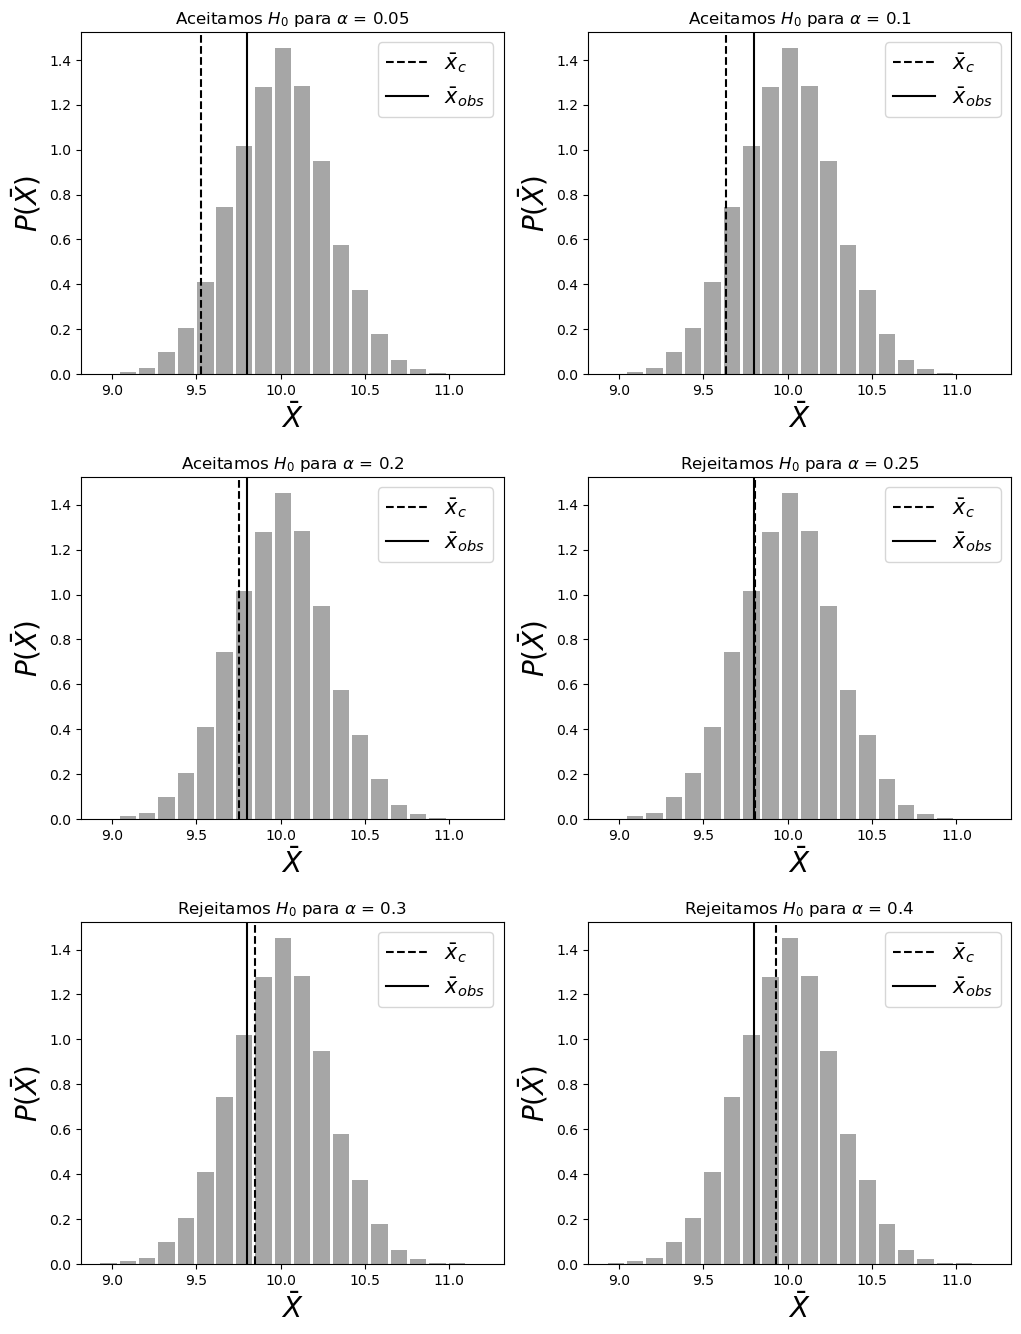

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
mu = 10 # média populacional
sigma = 2 # desvio padrão
n = 50 # tamanho da amostra
xobs = 9.8 # média da amostra
Ns = 10000 # número de simulações
Xm=[] # distribuição da média amostral
for s in range(1,Ns):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    Xm.append(np.mean(x))

plt.figure(figsize=(12,16))
plt.subplots_adjust(hspace=0.3)
alphas = [5,10,20,25, 30,40]
aux = 0
for alpha in alphas:
    # determina o valor crítico
    xc = np.percentile(Xm, alpha)
    plt.subplot(3, 2, aux + 1)
    aux = aux + 1
    # mostra os resultados
    plt.hist(x=Xm, bins=20, color='gray',
             alpha=0.7, rwidth=0.85, density=True)
    plt.axvline(x=xc, color='black',
                linestyle='--', label = r'$\bar{x}_c$')
    plt.axvline(x=xobs, color='black',
                linestyle='-', label = r'$\bar{x}_{obs}$')
    plt.xlabel(r'$\bar{X}$', fontsize=20)
    plt.ylabel(r'$P(\bar{X})$', fontsize=20)
    plt.legend(fontsize=15)
    if(xobs < xc):
        plt.title("Rejeitamos $H_0$ para"+r' $\alpha$ = ' +
                  str(alpha/100))
    else:
        plt.title("Aceitamos $H_0$ para"+r' $\alpha$ = ' +
                  str(alpha/100))
plt.show(True)

Podemos calcular o valor p: $P(\bar{X} > \bar{x}_{obs}|\mu=\mu_0) = \alpha$:

In [ ]:
pvalue = 0
for i in range(0, len(Xm)):
    if(Xm[i] < xobs):
        pvalue = pvalue + 1
pvalue = pvalue/len(Xm)
print('P-valor: ', pvalue)

P-valor:  0.2371237123712371


Mostrando no gráfico.

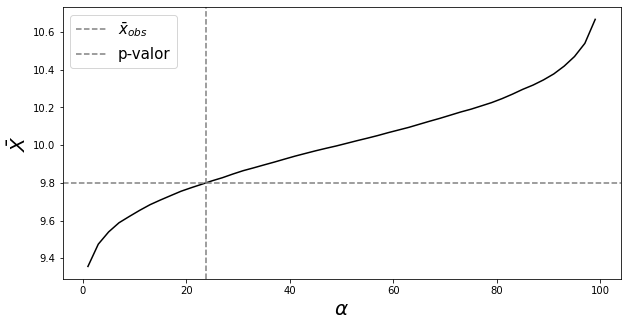

In [ ]:
xobs = 9.8
xcs = []
alphas = []
for alpha in np.arange(1,100,2):
    xc = np.percentile(Xm, alpha)
    xcs.append(xc)
    alphas.append(alpha)

plt.figure(figsize=(10,5))
plt.plot(alphas,xcs, color='black')
plt.axhline(y=xobs, color='gray', linestyle='--', label = r'$\bar{x}_{obs}$')
plt.axvline(x=pvalue*100, color='gray', linestyle='--', label = 'p-valor')
plt.xlabel(r'$\alpha$', fontsize=20)
plt.ylabel(r'$\bar{X}$', fontsize=20)
plt.legend(fontsize=15)
plt.show(True)

**Exemplo:** Estudantes acreditam que a média da turma em um curso de estatística é igual a 65. O professor acredita que a média é maior. Para verificar essas hipóteses, ele seleciona notas de 10 estudantes, obtemos os valores 65 65 70 67 66 63 63 68 72 71.  Assuma que as notas são normalmente distribuídas, calcule o valor p.

In [ ]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

# Dados do problema
mu = 65
n = 10
amostra = np.array([65, 65, 70, 67, 66, 63, 63, 68, 72, 71])

# Hipóteses
# H0: mu = 65 (a média da turma é igual a 65)
# H1: mu > 65 (a média da turma é maior que 65)

# Cálculo da média amostral e do desvio padrão amostral
media_amostral = np.mean(amostra)
desvio_padrao_amostral = np.std(amostra, ddof=1)  # ddof=1 para desvio padrão amostral

# Cálculo do valor p
t_stat = (media_amostral - mu) / (desvio_padrao_amostral / np.sqrt(n))
p_value = 1 - st.t.cdf(t_stat, df=n - 1)

print(f"Valor p: {p_value}")

nivel_significancia = 0.05
if p_value < nivel_significancia:
    print("Rejeita-se H0. A média da turma é maior que 65.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que a média da turma é maior que 65.")

Valor p: 0.03964824393588806
Rejeita-se H0. A média da turma é maior que 65.


Logo, o valor p é igual 0,039, indicando uma forte evidência para rejeitarmos $H_0$.



---



**Exemplo:** Calcule o valor p para as hipóteses abaixo, onde $\sigma = 10$, $n=20$ e $x_{obs} = 100$:<br>
> $H_0$: $\mu$ = 100<br>
> $H_a$: $\mu$ > 100<br>


In [ ]:
import numpy as np
np.random.seed(10)

mu = 100 # H0: média = 100
sigma = 20 # desvio padrão
xobs = 110 # valor observado
n = 20 # tamanho da amostra
sucesso = 0 # número de vezes que Ha é observada
ns = 1000 # número de simulações
for s in range(0,ns):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # se Ha é verifica:
    if(np.mean(x) > xobs):
        sucesso = sucesso + 1
print('Valor p =', sucesso/ns)

Valor p = 0.013


Calculando teoricamente:

In [ ]:
import scipy.stats

talpha = (xobs - mu)/(sigma/np.sqrt(n))
alpha = scipy.stats.t.cdf(talpha, n-1)
print('Valor p =',1 - alpha)

Valor p = 0.01877027477426252




---



**Exemplo:** O departamento de obras de uma cidade abriu uma nova rota para melhorar o fluxo de carros no centro da cidade.  Dados anteriores mostram que o tempo para ir do subúrbio ao centro é uma variável aleatória com distribuição normal com média $\mu = 30$ minutos e desvio padrão $\sigma = 3$ minutos. As 10 primeiras viagens considerando a nova rota resultaram em uma média igual 28 minutos. Esse resultado mostra que nova rota é mais rápida do que a anterior?


A hipótese nula é a que aceitamos sem realizar qualquer experimento. Ou seja, assumimos que essa nova rota é igual à anterior, não levando a nenhuma melhora nesse tempo. Assim,
$$
\begin{aligned}
& H_0: \mu = 30 \text{ minutos}\\
& H_1: \mu < 30 \text{ minutos}
\end{aligned}
$$

Usando a definição do valor-p:
$$
\begin{aligned}
P(\bar{X} < 28 | \mu = 30) &= P\left(\frac{\bar{X}-\mu}{\sigma /\sqrt{n}} < \frac{28 - \mu}{\sigma/\sqrt{n}}\Big| \mu = 30  \right)\\
& = P\left(Z < \frac{28 - 30}{3/\sqrt{10}}\right) \\
& = P(Z < -2,11) = 0,02.
\end{aligned}
$$
Logo, como o valor p é igual a 0,02, há uma forte evidência para rejeitarmos $H_0$, ou seja,  há evidências de que a nova rota  diminui o tempo do trajeto do subúrbio ao centro da cidade.

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
mu = 30  # Média antiga
sigma = 3  # Desvio padrão
n = 10  # Número de viagens
media_amostral = 28  # Média da nova rota

# Hipóteses
# H0: mu = 30 (a nova rota não é mais rápida)
# H1: mu < 30 (a nova rota é mais rápida)

# Cálculo do valor p
z_stat = (media_amostral - mu) / (sigma / np.sqrt(n))
p_value = st.norm.cdf(z_stat)

print(f"Valor p: {p_value}")

nivel_significancia = 0.05  # Nível de significância (5%)
if p_value < nivel_significancia:
    print("Rejeita-se H0. A nova rota é mais rápida.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que a nova rota é mais rápida.")

Valor p: 0.017507490509831244
Rejeita-se H0. A nova rota é mais rápida.




---



**Exemplo:** Assume-se que pressão arterial humana tem média igual a $\mu = 120$ mm Hg.  Em um estudo com um grupo de $n=10$ pacientes idosos, observou-se uma pressão média igual a 130,1 mmHg e desvio padrão 21,21 mmHg.  Esse grupo tem pressão arterial mais alta do que a população em geral?


Vamos considerar as hipóteses:
$$
\begin{aligned}
& H_0: \mu = 120 \text{ mmHg}\\
& H_1: \mu > 120 \text{ mmHg}
\end{aligned}
$$
Notem que a variância da população é desconhecida. Logo, devemos usar a distribuição t de Student, já que a amostra é pequena.  Desse modo,  calculando o valor-p:
$$
\begin{aligned}
P(\bar{X} >130,1 |\mu =120) &= P\left(\frac{\bar{X} - \mu}{s/\sqrt{n}} > \frac{130,1 - \mu}{s/\sqrt{n}}\Big| \mu = 120 \right) \\
&= P\left( T >  \frac{130,1-120}{21,21/\sqrt{10}}\right)\\
&= P( T > 1,505) \\
& = 1- P(T < 1,505) \\
& = 1 - 0,92\\
& = 0,08
\end{aligned}
$$
Logo,  como o valor-p é igual a 0,08,  não há evidências para rejeitarmos $H_0$, ou seja,  para afirmar que a pressão arterial do grupo de idosos é maior do que a da população em geral.

In [ ]:
import scipy.stats as st
import numpy as np

# Dados do problema
mu = 120  # Média populacional
n = 10    # Tamanho da amostra
media_amostral = 130.1  # Média amostral
desvio_padrao_amostral = 21.21  # Desvio padrão amostral

# Hipóteses
# H0: mu = 120 (a pressão arterial do grupo é igual à da população)
# H1: mu > 120 (a pressão arterial do grupo é maior que a da população)

# Cálculo do valor p (usando a distribuição t de Student, pois o desvio padrão populacional é desconhecido)
t_stat = (media_amostral - mu) / (desvio_padrao_amostral / np.sqrt(n))
p_value = 1 - st.t.cdf(t_stat, df=n - 1)

print(f"Valor p: {p_value}")

nivel_significancia = 0.05  # Nível de significância (5%)
if p_value < nivel_significancia:
    print("Rejeita-se H0. O grupo de pacientes idosos tem pressão arterial mais alta.")
else:
    print("Falha em rejeitar H0. Não há evidências suficientes para afirmar que o grupo de pacientes idosos tem pressão arterial mais alta.")

Valor p: 0.0831848296795692
Falha em rejeitar H0. Não há evidências suficientes para afirmar que o grupo de pacientes idosos tem pressão arterial mais alta.


Podemos simular esse problema usando o método de Monte Carlo.

In [ ]:
import numpy as np
np.random.seed(10)

# Dados do problema
mu = 120  # Média populacional
n = 10    # Tamanho da amostra
media_amostral = 130.1  # Média amostral
desvio_padrao_amostral = 21.21  # Desvio padrão amostral

# Hipóteses
# H0: mu = 120 (a pressão arterial do grupo é igual à da população)
# H1: mu > 120 (a pressão arterial do grupo é maior que a da população)

sucesso = 0 # número de vezes que Ha é observada
ns = 1000 # número de simulações
for s in range(0,ns):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, desvio_padrao_amostral, n)
    # se Ha é verifica:
    if(np.mean(x) > media_amostral):
        sucesso = sucesso + 1
print('Valor p =', sucesso/ns)

Valor p = 0.069
